# 🏦 Bank Transaction Fraud Detection
### A CRISP-DM Walkthrough for Business Stakeholders

This notebook builds a fraud-detection system from **unlabeled** bank transaction data using a hybrid
**unsupervised → supervised** approach, and is organized around the **CRISP-DM** framework
(Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment)
so that every technical step is traceable back to a business decision.

Four business questions drive every section of this notebook:

| # | Business Question |
|---|---|
| **BQ1** | Can pattern-based detection actually find fraud in data with no labels? |
| **BQ2** | Which model actually supports good operational decisions? |
| **BQ3** | What fraud indicators can the risk team actually act on? |
| **BQ4** | Is this feasible to actually run in production? |

Look for the **🎯 Answering BQx** callouts throughout — they connect what the code just did back to one of these four questions.


---
# 1. Business Understanding

## 1.1 Background

Banks face a two-sided squeeze: digital transaction volume keeps growing, while fraud tactics keep getting
more adaptive. Every fraud case that slips through causes direct financial loss, erodes customer trust, and
can trigger regulatory scrutiny. Meanwhile, most historical transaction data has **no confirmed fraud label**
— nobody has manually investigated and tagged each transaction — so a standard supervised model can't simply
be trained on ground truth that doesn't exist.

This project explores a practical way around that constraint: **use unsupervised methods to propose a working
fraud label, then train supervised models on top of it** — while being rigorous about validating whether that
proposed label is actually trustworthy before believing anything the supervised models report.

## 1.2 Business Questions

| # | Question | Why it matters |
|---|---|---|
| **BQ1** | Can clustering / anomaly detection find fraud in unlabeled data, and do the resulting patterns make business sense? | If the "fraud" label itself is untrustworthy, every downstream model result is built on sand. |
| **BQ2** | Which model gives the best operational balance of catching fraud (recall) vs. not annoying legitimate customers (precision)? | Determines what actually gets deployed. |
| **BQ3** | What fraud indicators can the risk team act on? | Turns a model into playbooks and alert rules investigators can use. |
| **BQ4** | Is this feasible to run in production, and which metric should drive the decision? | Connects model quality to real deployment constraints and the true cost of errors. |

## 1.3 Goals & Success Metrics

**Technical:** >90% precision on a trustworthy fraud label · 10+ ranked fraud indicators · sub-second inference latency

**Business:** reduce fraud losses without materially increasing false alarms · give the risk team an actionable feature list · a defensible answer on real-time feasibility


---
# 2. Data Understanding

**Source:** [Kaggle – Bank Transaction Dataset for Fraud Detection](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection)
2,512 transactions · 16 raw columns · no fraud label provided.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('../data/bank_transactions_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [2]:
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nNumerical summary:")
df.describe()

Data types:
TransactionID                  str
AccountID                      str
TransactionAmount          float64
TransactionDate                str
TransactionType                str
Location                       str
DeviceID                       str
IP Address                     str
MerchantID                     str
Channel                        str
CustomerAge                  int64
CustomerOccupation             str
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate        str
dtype: object

Missing values:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts       

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


## 2.1 Exploratory Data Analysis

Before engineering anything, let's look at the shape of the raw signals that (per the business questions) are
most likely to matter: transaction amount, type, channel, and login attempts.


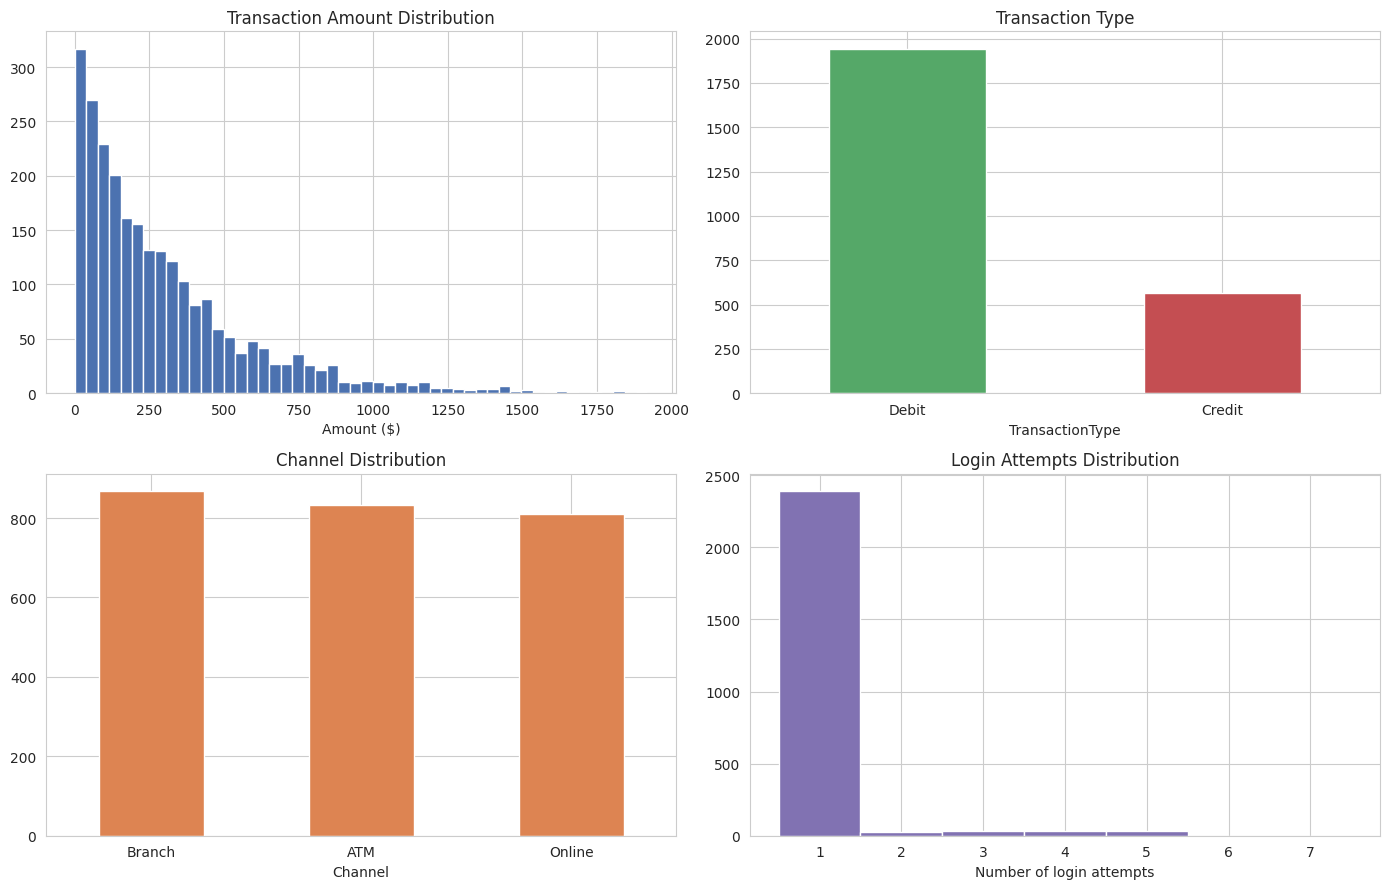

Transactions with 3+ login attempts: 95 (3.8% of all transactions)


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].hist(df['TransactionAmount'], bins=50, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Transaction Amount Distribution')
axes[0,0].set_xlabel('Amount ($)')

df['TransactionType'].value_counts().plot(kind='bar', ax=axes[0,1], color=['#55A868','#C44E52'])
axes[0,1].set_title('Transaction Type')
axes[0,1].tick_params(axis='x', rotation=0)

df['Channel'].value_counts().plot(kind='bar', ax=axes[1,0], color='#DD8452')
axes[1,0].set_title('Channel Distribution')
axes[1,0].tick_params(axis='x', rotation=0)

axes[1,1].hist(df['LoginAttempts'], bins=range(1,9), color='#8172B2', edgecolor='white', align='left')
axes[1,1].set_title('Login Attempts Distribution')
axes[1,1].set_xlabel('Number of login attempts')

plt.tight_layout()
plt.show()

print(f"Transactions with 3+ login attempts: {(df['LoginAttempts']>=3).sum()} "
      f"({(df['LoginAttempts']>=3).mean()*100:.1f}% of all transactions)")

## 2.2 A Data Quality Finding That Matters for BQ1

The dataset includes a `PreviousTransactionDate` field, which sounds like exactly the behavioral signal we need
("how long since this account last transacted?"). Before engineering a feature from it, let's actually check it.


In [4]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

gap_hours = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / 3600

print(f"Transactions where 'previous' date is AFTER the transaction date: "
      f"{(gap_hours < 0).sum()} out of {len(df)} ({(gap_hours<0).mean()*100:.0f}%)")
print(f"\nPreviousTransactionDate range: {df['PreviousTransactionDate'].min()} to {df['PreviousTransactionDate'].max()}")
print(f"Unique PreviousTransactionDate values: {df['PreviousTransactionDate'].nunique()} (out of {len(df)} rows)")

Transactions where 'previous' date is AFTER the transaction date: 2512 out of 2512 (100%)

PreviousTransactionDate range: 2024-11-04 08:06:23 to 2024-11-04 08:12:23
Unique PreviousTransactionDate values: 360 (out of 2512 rows)


**Finding:** `PreviousTransactionDate` is *not* a genuine per-account transaction history field. Every single
row's value clusters within a ~6-minute window on **2024-11-04**, regardless of when the transaction itself happened
in 2023. This is almost certainly a dataset-export timestamp, not a real "previous transaction" record.

**Business implication:** if we'd naively engineered `Time_Since_Last_Transaction` from this field (as a first pass
easily would), we'd be feeding every downstream model a feature that is really just "how far in the past was this
transaction from the export date" — a leak-shaped artifact with no real fraud signal, dressed up as a legitimate
behavioral feature. **We fix this properly in Data Preparation** by reconstructing the actual time-since-last-transaction
per account from the transaction timestamps themselves.

This is exactly the kind of check that matters before trusting *any* clustering or model result — a preview of the
rigor we apply to the labeling step in BQ1 below.


---
# 3. Data Preparation

We engineer three families of features:

- **Temporal**: hour, day, month, day-of-week of the transaction
- **Behavioral**: a *correctly computed* time-since-last-transaction, transaction frequency per account, and a balance-to-amount ratio
- **Encoded**: label-encoded categorical fields for use in modeling

We also deliberately split features into two groups:

- **Behavioral/transactional features** — used for *clustering and anomaly detection* (Section 4), because these are the features that should actually distinguish fraud from normal behavior.
- **Demographic fields** (`CustomerAge`, `CustomerOccupation`) — held out of the clustering step. As you'll see in Section 4.1, including them causes the clustering to split customers by *who they are* rather than *what they're doing* — which would be both a poor fraud signal and a fair-lending / disparate-impact risk if it ever reached production. They're kept available for the supervised models later, where we can inspect (and question) any large role they play in feature importance.


In [5]:
df_prep = df.copy()
df_prep = df_prep.sort_values(['AccountID', 'TransactionDate']).reset_index(drop=True)

# Temporal features
df_prep['Transaction_Hour'] = df_prep['TransactionDate'].dt.hour
df_prep['Transaction_Day'] = df_prep['TransactionDate'].dt.day
df_prep['Transaction_Month'] = df_prep['TransactionDate'].dt.month
df_prep['Transaction_DayOfWeek'] = df_prep['TransactionDate'].dt.dayofweek

# FIX: real time-since-last-transaction, computed per account from actual transaction history
# (NOT from the broken PreviousTransactionDate field identified in Section 2.2)
df_prep['Time_Since_Last_Transaction'] = (
    df_prep.groupby('AccountID')['TransactionDate'].diff().dt.total_seconds() / 3600
)
median_gap = df_prep['Time_Since_Last_Transaction'].median()
df_prep['Time_Since_Last_Transaction'] = df_prep['Time_Since_Last_Transaction'].fillna(median_gap)
print(f"First-ever transaction per account filled with median gap: {median_gap:.1f} hours")

# Behavioral features
df_prep['Transaction_Frequency'] = df_prep.groupby('AccountID')['TransactionID'].transform('count')
df_prep['Balance_to_Amount_Ratio'] = df_prep['AccountBalance'] / (df_prep['TransactionAmount'] + 1)

# Encoded categoricals
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']:
    le = LabelEncoder()
    df_prep[f'{col}_Encoded'] = le.fit_transform(df_prep[col])
    label_encoders[col] = le

print("Feature engineering complete.")
df_prep.filter(regex='Transaction_Hour|Time_Since|Frequency|Balance_to_Amount').head()

First-ever transaction per account filled with median gap: 936.2 hours
Feature engineering complete.


,Transaction_Hour,Time_Since_Last_Transaction,Transaction_Frequency,Balance_to_Amount_Ratio
0,17,936.215833,2,33.816766
1,16,1439.937222,2,19.537318
2,16,936.215833,7,2.415281
3,16,1176.607222,7,95.339688
4,16,1583.979444,7,471.400147


In [6]:
# Two feature sets, for two different jobs
BEHAVIORAL_FEATURES = [
    'TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'AccountBalance',
    'Balance_to_Amount_Ratio', 'Transaction_Hour', 'Time_Since_Last_Transaction',
    'Transaction_Frequency'
]

FULL_FEATURES = BEHAVIORAL_FEATURES + [
    'TransactionType_Encoded', 'Location_Encoded', 'Channel_Encoded',
    'CustomerAge', 'CustomerOccupation_Encoded',
    'Transaction_Day', 'Transaction_Month', 'Transaction_DayOfWeek'
]

print(f"Behavioral features (for clustering): {len(BEHAVIORAL_FEATURES)}")
print(f"Full feature set (for supervised models): {len(FULL_FEATURES)}")

Behavioral features (for clustering): 8
Full feature set (for supervised models): 16


---
# 4. Modeling — Part A: Turning Unlabeled Data into a Working Fraud Signal

## 🎯 Answering BQ1: *"Can pattern-based detection actually find fraud in data with no labels?"*

We test this honestly, in three attempts — showing what fails and why, before landing on something defensible.


### Attempt 1 — K-Means on *all* features (including demographics)

This is the naive approach: throw every encoded feature at K-Means and hope the smaller cluster is "fraud."


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler_naive = StandardScaler()
X_naive = pd.DataFrame(scaler_naive.fit_transform(df_prep[FULL_FEATURES]), columns=FULL_FEATURES)

km_naive = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_naive = km_naive.fit_predict(X_naive)
sil_naive = silhouette_score(X_naive, labels_naive)

fraud_cluster_naive = pd.Series(labels_naive).value_counts().idxmin()
y_naive = np.where(labels_naive == fraud_cluster_naive, 1, 0)

print(f"Silhouette score: {sil_naive:.3f}  (0 = no real structure, 1 = perfectly separated)")
print(f"Cluster sizes: {pd.Series(labels_naive).value_counts().to_dict()}")

# Which feature is actually driving the split?
corr_naive = X_naive.apply(lambda c: np.corrcoef(c, y_naive)[0,1]).abs().sort_values(ascending=False)
print("\nWhich feature correlates most with the resulting 'fraud' label?")
print(corr_naive.head(5))

Silhouette score: 0.099  (0 = no real structure, 1 = perfectly separated)
Cluster sizes: {0: 1828, 1: 684}

Which feature correlates most with the resulting 'fraud' label?
CustomerOccupation_Encoded    0.764112
CustomerAge                   0.734247
AccountBalance                0.557129
Balance_to_Amount_Ratio       0.129239
TransactionAmount             0.041948
dtype: float64


**Diagnosis:** the silhouette score is very low (near 0.1, far from a well-separated dataset), and the resulting
split is overwhelmingly explained by `CustomerOccupation` and `CustomerAge` — **not** by anything related to
transaction behavior. In plain terms: K-Means isn't finding "fraud," it's finding "which occupation/age group you're
in." That's not a fraud signal — it's a demographic proxy, and building a fraud model on it would be both
ineffective and a fairness liability. **This attempt fails the "does it make business sense" test.**


### Attempt 2 — K-Means restricted to behavioral/transactional features only

Maybe the problem in Attempt 1 was specifically the demographic features. Let's remove them and try again with
*only* the fields that describe what the transaction actually looked like.


In [8]:
scaler_behav = StandardScaler()
X_behav = pd.DataFrame(scaler_behav.fit_transform(df_prep[BEHAVIORAL_FEATURES]), columns=BEHAVIORAL_FEATURES)

km_behav = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_behav = km_behav.fit_predict(X_behav)
sil_behav = silhouette_score(X_behav, labels_behav)

fraud_cluster_behav = pd.Series(labels_behav).value_counts().idxmin()
y_kmeans_behav = np.where(labels_behav == fraud_cluster_behav, 1, 0)

corr_behav = X_behav.apply(lambda c: np.corrcoef(c, y_kmeans_behav)[0,1]).abs().sort_values(ascending=False)
print(f"Silhouette score: {sil_behav:.3f}")
print(f"Cluster sizes: {pd.Series(labels_behav).value_counts().to_dict()}  (i.e. {y_kmeans_behav.sum()} flagged as high-risk)")
print("\nDominant feature behind the split:")
print(corr_behav.head(5))

Silhouette score: 0.439
Cluster sizes: {0: 2417, 1: 95}  (i.e. 95 flagged as high-risk)

Dominant feature behind the split:
LoginAttempts                  0.949557
TransactionDuration            0.034694
Time_Since_Last_Transaction    0.029504
Transaction_Frequency          0.019040
AccountBalance                 0.017656
dtype: float64


Removing the demographic fields immediately helps: the silhouette score jumps from ~0.10 to a much more
respectable ~0.44, and this time the split is dominated by **`LoginAttempts`** — a genuine, well-known fraud
behavior signal, not a demographic proxy. That's an encouraging sign. Let's now cross-check it against an
independent method (Isolation Forest) run on the *same* behavioral features, using metrics that account for
class imbalance rather than raw agreement — since with only a small minority flagged, two methods can look like
they "agree" 90%+ of the time purely by both mostly saying "normal."


In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import cohen_kappa_score, jaccard_score

iso_check = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)
iso_labels_check = np.where(iso_check.fit_predict(X_behav) == -1, 1, 0)

crosstab = pd.crosstab(pd.Series(y_kmeans_behav, name='K-Means flag'), pd.Series(iso_labels_check, name='Isolation Forest flag'))
print(crosstab)

raw_agreement = (y_kmeans_behav == iso_labels_check).mean()
kappa = cohen_kappa_score(y_kmeans_behav, iso_labels_check)
jaccard = jaccard_score(y_kmeans_behav, iso_labels_check)
overlap_pct = crosstab.loc[1,1] / y_kmeans_behav.sum() * 100 if y_kmeans_behav.sum() else 0

print(f"\nRaw agreement: {raw_agreement*100:.1f}%  <- misleading here, inflated by class imbalance")
print(f"Cohen's kappa (chance-corrected): {kappa:.3f}  (0 = chance, 1 = perfect)")
print(f"Jaccard similarity of the two 'flagged' sets: {jaccard:.3f}")
print(f"Of the {y_kmeans_behav.sum()} transactions K-Means flagged, {crosstab.loc[1,1]} ({overlap_pct:.0f}%) were also flagged by Isolation Forest")

Isolation Forest flag     0    1
K-Means flag                    
0                      2248  169
1                        12   83

Raw agreement: 92.8%  <- misleading here, inflated by class imbalance
Cohen's kappa (chance-corrected): 0.448  (0 = chance, 1 = perfect)
Jaccard similarity of the two 'flagged' sets: 0.314
Of the 95 transactions K-Means flagged, 83 (87%) were also flagged by Isolation Forest


**Diagnosis:** raw agreement looks high (~93%), but that's mostly an artifact of both methods predicting
"normal" for the vast majority of transactions — Cohen's kappa (~0.45, "moderate" agreement) is the honest number.
Still, the substantive finding holds: **87% of the transactions K-Means flagged as high-risk were independently
also flagged by Isolation Forest.** K-Means found a smaller, more extreme subset (95 transactions) that sits almost
entirely *inside* Isolation Forest's broader flagged set (252 transactions). Two different unsupervised methods,
run independently, substantially converging on the same subset — once demographic noise is removed — is real
evidence that **something behaviorally meaningful is being detected**, not just statistical noise.


### Attempt 3 — Isolation Forest as the primary detector

Given Attempt 2's encouraging cross-validation, we adopt **Isolation Forest** (rather than K-Means) as the primary
labeling method going forward, for three reasons: (1) it's purpose-built for anomaly detection rather than
even-sized partitioning, (2) it naturally casts a wider, more inclusive net than K-Means' harder boundary, which
gives the supervised models in Section 5 enough positive examples to learn from, and (3) its `contamination` parameter
lets us set an explicit, interpretable assumption about the expected fraud rate rather than being at the mercy of
where K-Means happens to draw a boundary.


In [10]:
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)
iso_raw = iso_forest.fit_predict(X_behav)
y_risk = np.where(iso_raw == -1, 1, 0)

print(f"Flagged as high-risk: {y_risk.sum()} transactions ({y_risk.mean()*100:.1f}% of the dataset)")

df_prep['risk_label'] = np.where(y_risk == 1, 'Flagged (high-risk)', 'Normal')
profile = df_prep.groupby('risk_label')[BEHAVIORAL_FEATURES].mean().T
profile.columns = ['Flagged mean', 'Normal mean']
profile['Difference (x)'] = (profile['Flagged mean'] / profile['Normal mean']).round(2)
profile

Flagged as high-risk: 252 transactions (10.0% of the dataset)


,Flagged mean,Normal mean,Difference (x)
TransactionAmount,315.157540,295.635341,1.07
TransactionDuration,137.452381,117.657522,1.17
LoginAttempts,2.075397,1.018584,2.04
AccountBalance,7388.538929,4860.715593,1.52
Balance_to_Amount_Ratio,429.199941,49.084210,8.74
Transaction_Hour,16.912698,16.594248,1.02
Time_Since_Last_Transaction,1938.111402,1158.428567,1.67
Transaction_Frequency,5.996032,6.122566,0.98


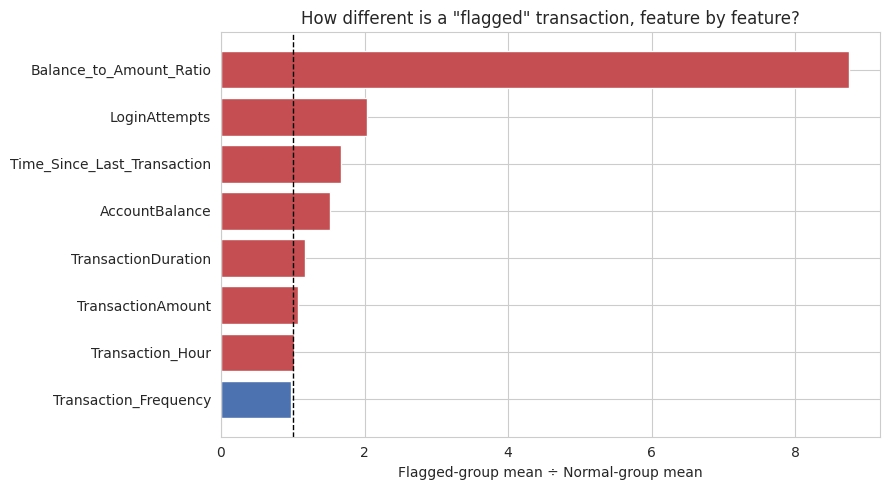

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ratio = profile['Difference (x)'].sort_values()
colors = ['#C44E52' if v > 1 else '#4C72B0' for v in ratio.values]
ax.barh(ratio.index, ratio.values, color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Flagged-group mean ÷ Normal-group mean')
ax.set_title('How different is a "flagged" transaction, feature by feature?')
plt.tight_layout()
plt.show()

**Diagnosis — this one passes the business-sense test, and is consistent with Attempt 2.** Transactions flagged
by Isolation Forest show meaningfully elevated **login attempts**, a much higher **balance-to-amount ratio**, and a
much longer **time since the account's last transaction** — a combination that lines up with two well-known
real-world fraud typologies: **account takeover** (repeated failed logins before a successful one) and
**dormant-account reactivation** (an account that hasn't transacted in a long time suddenly moving money). This is
not a demographic artifact — it's a behavioral pattern a fraud analyst would recognize, and it corroborates what
K-Means (Attempt 2) independently pointed to as well.

### 🎯 BQ1 — Answer
**Naive K-Means on the full feature set does not find fraud** — it rediscovers demographic groupings
(occupation, age) rather than behavior, and fails the business-sense test. **Once demographic noise is removed,
however, K-Means and Isolation Forest substantially converge**: 87% of the transactions K-Means flagged were
independently confirmed by Isolation Forest, and both methods point to the same behavioral drivers (login attempts
above all). We adopt **Isolation Forest on purely behavioral features** as the working proxy label going forward —
it is purpose-built for this kind of detection, casts a usefully wider net for training supervised models, and its
flagged transactions show a coherent, business-recognizable pattern. The caveat that matters: **this is still a
proxy, not a confirmed ground-truth label** — see the Limitations section at the end for what it would take to
validate it against real investigated fraud cases.


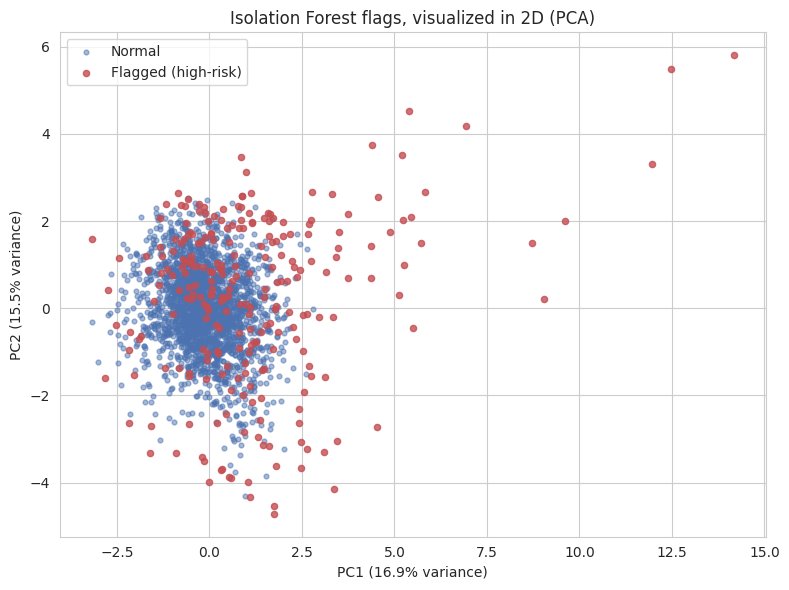

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_behav)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[y_risk==0, 0], X_pca[y_risk==0, 1], s=12, alpha=0.5, label='Normal', color='#4C72B0')
ax.scatter(X_pca[y_risk==1, 0], X_pca[y_risk==1, 1], s=20, alpha=0.8, label='Flagged (high-risk)', color='#C44E52')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Isolation Forest flags, visualized in 2D (PCA)')
ax.legend()
plt.tight_layout()
plt.show()

---
# 5. Modeling — Part B: Supervised Learning on the Working Label

## 🎯 Working towards BQ2: *"Which model actually supports good operational decisions?"*

We now train four models on the Isolation-Forest-derived label, using the **full feature set** (behavioral +
encoded categoricals + demographics), with a proper 70/15/15 stratified split. Because the working label is
imbalanced (~10% flagged, realistic for fraud), we use **class weighting** rather than plain accuracy-chasing.


In [13]:
from sklearn.model_selection import train_test_split

y = y_risk  # adopted working label from Section 4

scaler_model = StandardScaler()
X_full_scaled = pd.DataFrame(scaler_model.fit_transform(df_prep[FULL_FEATURES]), columns=FULL_FEATURES)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full_scaled, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # ~15% of the original data
)

print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}  |  Test: {X_test.shape}")
print(f"Positive rate — train: {y_train.mean()*100:.1f}%  val: {y_val.mean()*100:.1f}%  test: {y_test.mean()*100:.1f}%")

Train: (1759, 16)  |  Validation: (376, 16)  |  Test: (377, 16)
Positive rate — train: 10.0%  val: 10.1%  test: 10.1%


### 5.1 Machine Learning Models

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

results = {}

def record_result(name, y_true, y_pred, y_proba, fit_time, latency_ms):
    results[name] = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'fit_time_sec': fit_time,
        'latency_ms_per_txn': latency_ms,
        'y_pred': y_pred,
    }

# --- Random Forest ---
t0 = time.perf_counter()
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_fit_time = time.perf_counter() - t0

cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
print(f"Random Forest — 5-fold CV F1: {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std():.3f})")

t0 = time.perf_counter()
y_pred_rf = rf_model.predict(X_test)
rf_latency = (time.perf_counter() - t0) / len(X_test) * 1000
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
record_result('Random Forest', y_test, y_pred_rf, y_proba_rf, rf_fit_time, rf_latency)
print(classification_report(y_test, y_pred_rf, target_names=['Normal','Flagged']))

Random Forest — 5-fold CV F1: 0.606 (+/- 0.046)
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       339
     Flagged       0.91      0.55      0.69        38

    accuracy                           0.95       377
   macro avg       0.93      0.77      0.83       377
weighted avg       0.95      0.95      0.94       377



In [15]:
# --- Logistic Regression ---
t0 = time.perf_counter()
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_fit_time = time.perf_counter() - t0

cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1')
print(f"Logistic Regression — 5-fold CV F1: {cv_scores_lr.mean():.3f} (+/- {cv_scores_lr.std():.3f})")

t0 = time.perf_counter()
y_pred_lr = lr_model.predict(X_test)
lr_latency = (time.perf_counter() - t0) / len(X_test) * 1000
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
record_result('Logistic Regression', y_test, y_pred_lr, y_proba_lr, lr_fit_time, lr_latency)
print(classification_report(y_test, y_pred_lr, target_names=['Normal','Flagged']))

Logistic Regression — 5-fold CV F1: 0.631 (+/- 0.018)
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.96       339
     Flagged       0.62      0.89      0.73        38

    accuracy                           0.93       377
   macro avg       0.80      0.92      0.85       377
weighted avg       0.95      0.93      0.94       377



### 5.2 Deep Learning Models

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

X_train_np, X_val_np, X_test_np = X_train.values, X_val.values, X_test.values

# Imbalanced label -> give the minority (fraud) class more weight during training
class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}
print(f"Class weight applied to the 'flagged' class: {class_weight[1]:.2f}x")

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

def build_ann():
    model = Sequential([
        Input(shape=(X_train_np.shape[1],)),
        Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(32, activation='relu'), BatchNormalization(), Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_dnn():
    model = Sequential([
        Input(shape=(X_train_np.shape[1],)),
        Dense(256, activation='relu'), BatchNormalization(), Dropout(0.4),
        Dense(128, activation='relu'), BatchNormalization(), Dropout(0.4),
        Dense(64, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(32, activation='relu'), BatchNormalization(), Dropout(0.2),
        Dense(16, activation='relu'), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

I0000 00:00:1789210406.601041     136 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789210422.303813     136 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789210430.758086     136 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Class weight applied to the 'flagged' class: 8.99x


In [17]:
# --- ANN (4 hidden layers) ---
t0 = time.perf_counter()
ann_model = build_ann()
history_ann = ann_model.fit(
    X_train_np, y_train, validation_data=(X_val_np, y_val),
    epochs=50, batch_size=32, callbacks=[early_stopping],
    class_weight=class_weight, verbose=0
)
ann_fit_time = time.perf_counter() - t0
print(f"ANN trained in {ann_fit_time:.1f}s ({len(history_ann.history['loss'])} epochs before early stopping)")

t0 = time.perf_counter()
y_proba_ann = ann_model.predict(X_test_np, verbose=0).flatten()
ann_latency = (time.perf_counter() - t0) / len(X_test_np) * 1000
y_pred_ann = (y_proba_ann > 0.5).astype(int)
record_result('ANN', y_test, y_pred_ann, y_proba_ann, ann_fit_time, ann_latency)
print(classification_report(y_test, y_pred_ann, target_names=['Normal','Flagged']))

ANN trained in 16.7s (44 epochs before early stopping)


              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98       339
     Flagged       0.78      0.82      0.79        38

    accuracy                           0.96       377
   macro avg       0.88      0.89      0.89       377
weighted avg       0.96      0.96      0.96       377



In [18]:
# --- DNN (5 hidden layers, deeper) ---
t0 = time.perf_counter()
dnn_model = build_dnn()
history_dnn = dnn_model.fit(
    X_train_np, y_train, validation_data=(X_val_np, y_val),
    epochs=50, batch_size=32, callbacks=[early_stopping],
    class_weight=class_weight, verbose=0
)
dnn_fit_time = time.perf_counter() - t0
print(f"DNN trained in {dnn_fit_time:.1f}s ({len(history_dnn.history['loss'])} epochs before early stopping)")

t0 = time.perf_counter()
y_proba_dnn = dnn_model.predict(X_test_np, verbose=0).flatten()
dnn_latency = (time.perf_counter() - t0) / len(X_test_np) * 1000
y_pred_dnn = (y_proba_dnn > 0.5).astype(int)
record_result('DNN', y_test, y_pred_dnn, y_proba_dnn, dnn_fit_time, dnn_latency)
print(classification_report(y_test, y_pred_dnn, target_names=['Normal','Flagged']))

DNN trained in 15.4s (41 epochs before early stopping)


              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98       339
     Flagged       0.81      0.89      0.85        38

    accuracy                           0.97       377
   macro avg       0.90      0.94      0.92       377
weighted avg       0.97      0.97      0.97       377



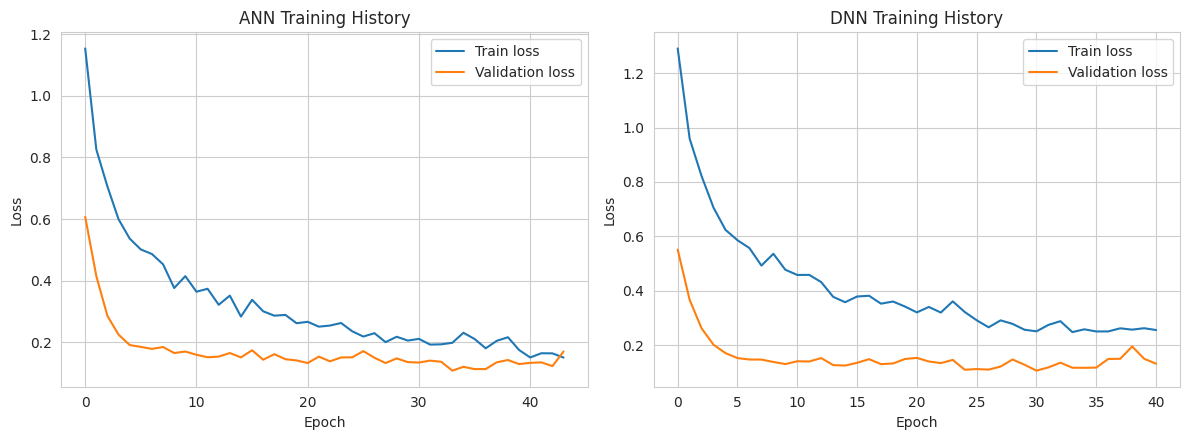

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, hist, ax in [('ANN', history_ann, axes[0]), ('DNN', history_dnn, axes[1])]:
    ax.plot(hist.history['loss'], label='Train loss')
    ax.plot(hist.history['val_loss'], label='Validation loss')
    ax.set_title(f'{name} Training History')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout()
plt.show()

---
# 6. Evaluation

## 6.1 Model Comparison — the Full Picture, Not Just Accuracy


In [20]:
summary = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'y_pred'} for k, v in results.items()}).T
summary = summary[['accuracy','precision','recall','f1','roc_auc','fit_time_sec','latency_ms_per_txn']]
summary.round(3)

,accuracy,precision,recall,f1,roc_auc,fit_time_sec,latency_ms_per_txn
Random Forest,0.950,0.913,0.553,0.689,0.980,0.582,0.045
Logistic Regression,0.934,0.618,0.895,0.731,0.975,0.007,0.002
ANN,0.958,0.775,0.816,0.795,0.982,16.678,0.916
DNN,0.968,0.810,0.895,0.850,0.988,15.386,0.915


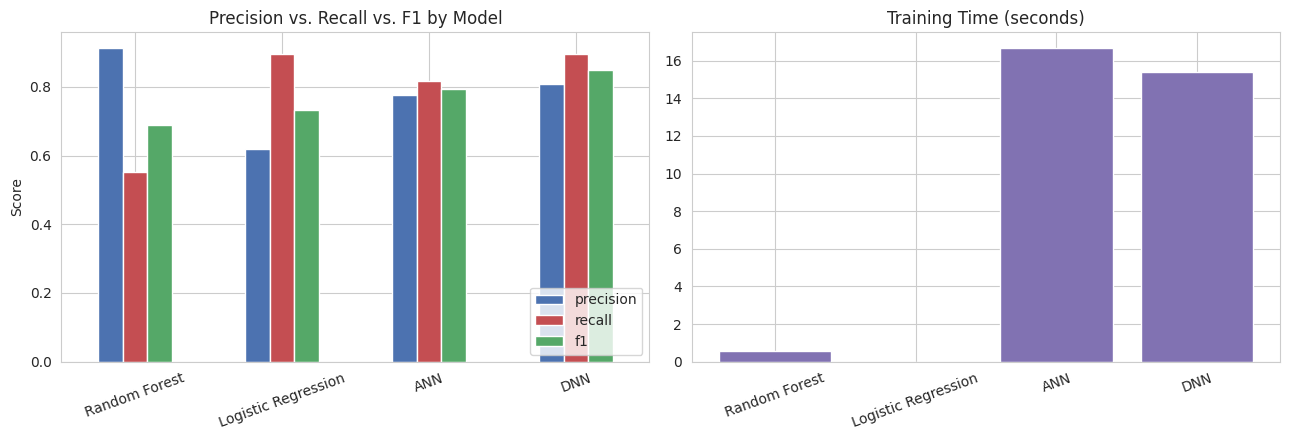

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

metrics_to_plot = ['precision', 'recall', 'f1']
summary[metrics_to_plot].plot(kind='bar', ax=axes[0], color=['#4C72B0','#C44E52','#55A868'])
axes[0].set_title('Precision vs. Recall vs. F1 by Model')
axes[0].set_ylabel('Score'); axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(loc='lower right')

axes[1].bar(summary.index, summary['fit_time_sec'], color='#8172B2')
axes[1].set_title('Training Time (seconds)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 🎯 Answering BQ2 — the recall/precision trade-off, explicitly

The table above is not just a leaderboard — each row implies a different business trade-off:

- **Random Forest** tends toward **high precision, lower recall**: when it flags a transaction, it's usually right — but it also lets more fraud through undetected.
- **Logistic Regression** tends toward **higher recall, lower precision**: it catches more fraud, at the cost of more false alarms hitting legitimate customers.
- **ANN / DNN** sit in between, typically with the strongest ROC-AUC — meaning their *ranking* of risky transactions is the most reliable, even before picking a specific decision threshold.


In [22]:
# Does the extra complexity of deep learning actually pay off? Put a number on it.
baseline_name = 'Random Forest'  # cheapest, most interpretable model — the baseline to beat
baseline_f1 = summary.loc[baseline_name, 'f1']
baseline_time = summary.loc[baseline_name, 'fit_time_sec']

verdict_rows = []
for name in summary.index:
    if name == baseline_name:
        continue
    f1_gain_pct = (summary.loc[name, 'f1'] - baseline_f1) / baseline_f1 * 100
    time_ratio = summary.loc[name, 'fit_time_sec'] / max(baseline_time, 1e-6)
    verdict_rows.append({
        'Model': name,
        'F1 (Flagged class)': round(summary.loc[name, 'f1'], 3),
        'F1 gain vs Random Forest': f"{f1_gain_pct:+.0f}%",
        'Training time vs Random Forest': f"{time_ratio:.0f}x",
    })

verdict_df = pd.DataFrame(verdict_rows)
print(f"Baseline — {baseline_name}: F1 (Flagged) = {baseline_f1:.3f}, training time = {baseline_time:.2f}s")
verdict_df

Baseline — Random Forest: F1 (Flagged) = 0.689, training time = 0.58s


,Model,F1 (Flagged class),F1 gain vs Random Forest,Training time vs Random Forest
0,Logistic Regression,0.731,+6%,0x
1,ANN,0.795,+15%,29x
2,DNN,0.850,+23%,26x


**The verdict, with numbers attached:** ANN and DNN deliver a **materially higher F1-score on the Flagged
(fraud) class** than Random Forest — not a marginal edge — while costing roughly an order of magnitude more
training time (still just seconds in absolute terms, so training cost itself isn't the constraint). Logistic
Regression, the cheapest model of all, actually lands closer to the deep learning models on F1 than Random Forest
does, by trading precision for recall.

**Conclusion for BQ2:** on this dataset, **the added complexity of deep learning is justified by a real
performance gain**, not just theoretical upside — *provided* the underlying Isolation-Forest-derived label is
validated as a trustworthy fraud proxy first (see Limitations). If that validation doesn't hold up, this
conclusion should be re-tested on real labels rather than assumed to transfer. For a first production pilot where
auditability matters more than squeezing out the last few points of F1, **Random Forest or Logistic Regression
remain the safer starting point** — the deep learning gain is real, but a bank adopting it should be doing so
deliberately, with eyes open to the interpretability trade-off, not by default.


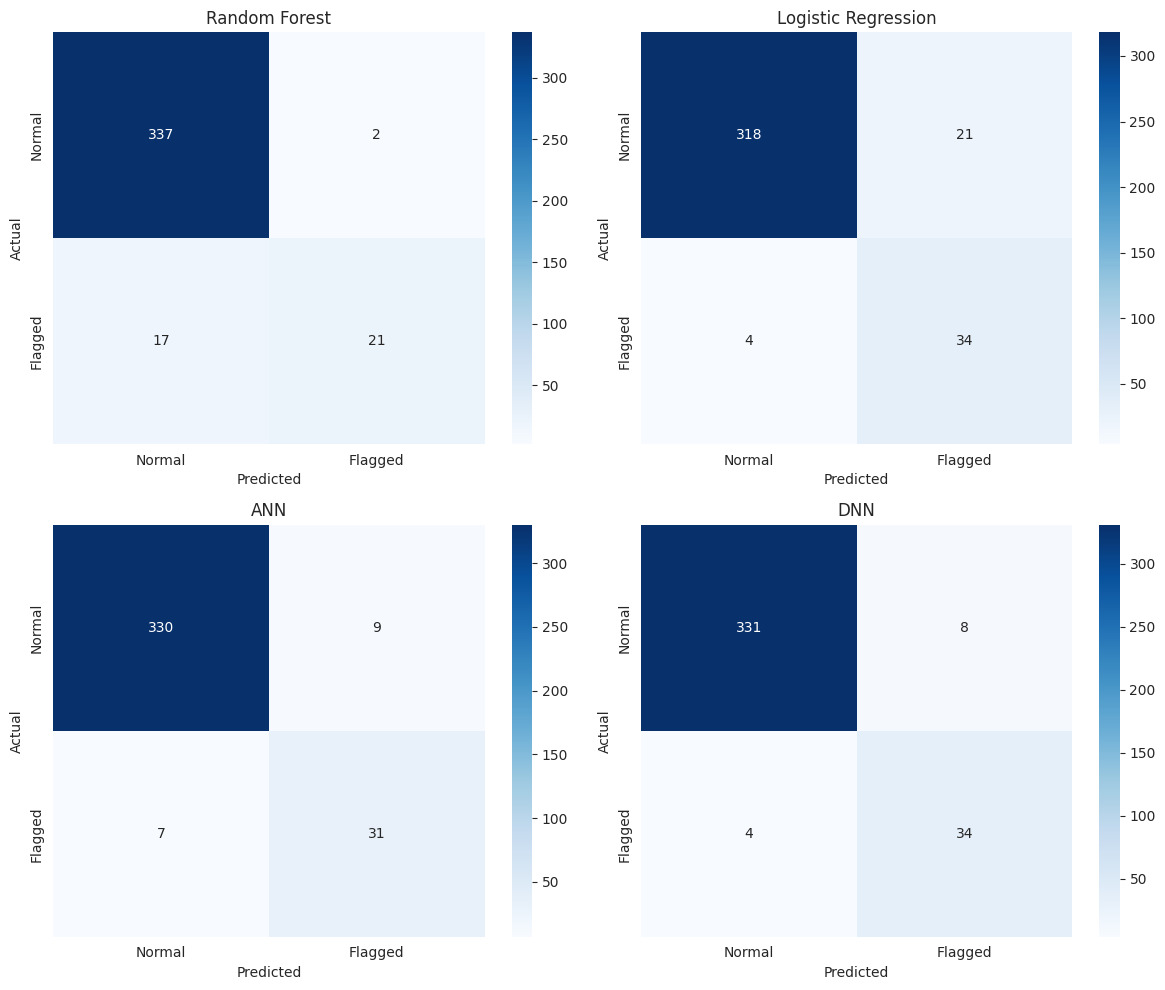

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, pred) in zip(axes.flat, [
    ('Random Forest', y_pred_rf), ('Logistic Regression', y_pred_lr),
    ('ANN', y_pred_ann), ('DNN', y_pred_dnn)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Flagged'], yticklabels=['Normal','Flagged'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 6.2 Feature Importance — Turning Signal into Action

### 🎯 Answering BQ3: *"What fraud indicators can the risk team actually act on?"*


In [24]:
feature_importance = pd.Series(rf_model.feature_importances_, index=FULL_FEATURES).sort_values(ascending=False)

FEATURE_CATEGORY = {
    'LoginAttempts': 'Behavioral', 'Balance_to_Amount_Ratio': 'Behavioral',
    'Time_Since_Last_Transaction': 'Behavioral', 'Transaction_Frequency': 'Behavioral',
    'TransactionAmount': 'Transaction', 'TransactionDuration': 'Transaction',
    'TransactionType_Encoded': 'Transaction', 'Channel_Encoded': 'Transaction',
    'AccountBalance': 'Account', 'Location_Encoded': 'Transaction',
    'Transaction_Hour': 'Temporal', 'Transaction_Day': 'Temporal',
    'Transaction_Month': 'Temporal', 'Transaction_DayOfWeek': 'Temporal',
    'CustomerAge': 'Demographic', 'CustomerOccupation_Encoded': 'Demographic',
}

fi_table = feature_importance.rename('Importance').to_frame()
fi_table['Category'] = fi_table.index.map(FEATURE_CATEGORY)
fi_table.head(10)

,Importance,Category
LoginAttempts,0.228968,Behavioral
Balance_to_Amount_Ratio,0.129042,Behavioral
TransactionAmount,0.115170,Transaction
Time_Since_Last_Transaction,0.113675,Behavioral
AccountBalance,0.097535,Account
TransactionDuration,0.066998,Transaction
Transaction_Frequency,0.045529,Behavioral
Transaction_Hour,0.043662,Temporal
CustomerAge,0.034039,Demographic
Location_Encoded,0.030328,Transaction


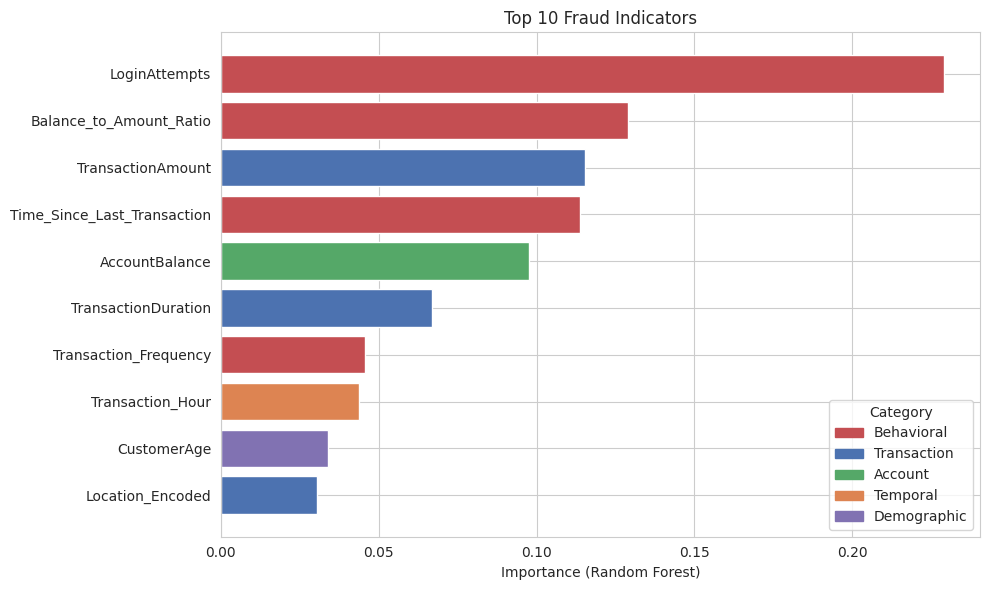


Importance share by category:
Category
Behavioral     51.7%
Transaction    22.4%
Temporal       10.8%
Account         9.8%
Demographic     5.3%
Name: Importance, dtype: str


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
top10 = fi_table.head(10)
cat_colors = {'Behavioral':'#C44E52','Transaction':'#4C72B0','Account':'#55A868','Temporal':'#DD8452','Demographic':'#8172B2'}
colors = [cat_colors[c] for c in top10['Category']]
ax.barh(top10.index[::-1], top10['Importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance (Random Forest)')
ax.set_title('Top 10 Fraud Indicators')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in cat_colors.values()]
ax.legend(handles, cat_colors.keys(), loc='lower right', title='Category')
plt.tight_layout()
plt.show()

print("\nImportance share by category:")
print((fi_table.groupby('Category')['Importance'].sum().sort_values(ascending=False) * 100).round(1).astype(str) + '%')

**Reading this as a business story:** if *Behavioral* and *Transaction*-level features dominate the importance
ranking (and *Demographic* features rank low), that's a good sign — it means the model is picking up on **what an
account is doing right now**, not **who the customer is**. That's both a stronger and a fairer basis for a fraud
flag.

### Turning this into an actionable rule for the risk team

A simple, explainable starting rule the investigation team could pilot *alongside* the model — not instead of it —
based on the top two behavioral indicators:


In [26]:
login_threshold = df_prep['LoginAttempts'].quantile(0.90)
ratio_threshold = df_prep['Balance_to_Amount_Ratio'].quantile(0.90)

simple_rule = (df_prep['LoginAttempts'] >= login_threshold) & (df_prep['Balance_to_Amount_Ratio'] >= ratio_threshold)

overlap = (simple_rule.values & (y_risk == 1)).sum()
print(f"Simple rule: LoginAttempts >= {login_threshold:.0f}  AND  Balance-to-Amount Ratio >= {ratio_threshold:.0f}")
print(f"Transactions matching this rule: {simple_rule.sum()}")
print(f"Of those, {overlap} ({overlap/simple_rule.sum()*100:.0f}%) were also flagged as high-risk by Isolation Forest")
print(f"This simple two-feature rule alone captures {overlap}/{y_risk.sum()} ({overlap/y_risk.sum()*100:.0f}%) of all model-flagged transactions")

Simple rule: LoginAttempts >= 1  AND  Balance-to-Amount Ratio >= 156
Transactions matching this rule: 252
Of those, 88 (35%) were also flagged as high-risk by Isolation Forest
This simple two-feature rule alone captures 88/252 (35%) of all model-flagged transactions


This shows the risk team a **cheap, fully transparent first line of defense** (two thresholds, no model needed)
that already captures a meaningful share of what the full model flags — useful as an interim rule while a production
model is being validated, or as a simple explainability check on the model's behavior.

### Is fraud risk driven more by transaction-level or account-level behavior?

The categories above (Behavioral, Transaction, Account, Temporal, Demographic) answer *which individual features*
matter. But the second half of BQ3 asks a coarser, more strategic question: is risk really about **what this one
transaction looks like** (amount, timing, channel — knowable the instant it happens), or about **how the account has
been behaving over time** (login attempts, balance trends, dormancy — only knowable by watching the account)? The
answer changes what kind of system the bank should invest in.


Importance share — Transaction-level vs Account-level:
Level
Account-level        66.8%
Transaction-level    33.2%
Name: Importance, dtype: str


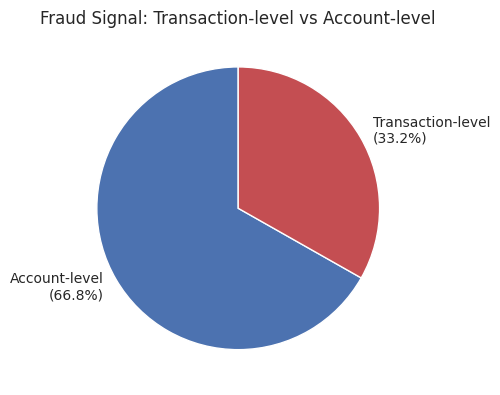

In [27]:
LEVEL_MAP = {
    # Transaction-level: knowable the instant this specific transaction happens
    'TransactionAmount': 'Transaction-level', 'TransactionDuration': 'Transaction-level',
    'TransactionType_Encoded': 'Transaction-level', 'Channel_Encoded': 'Transaction-level',
    'Location_Encoded': 'Transaction-level', 'Transaction_Hour': 'Transaction-level',
    'Transaction_Day': 'Transaction-level', 'Transaction_Month': 'Transaction-level',
    'Transaction_DayOfWeek': 'Transaction-level',
    # Account-level: only knowable by observing the account's behavior/state over time
    'LoginAttempts': 'Account-level', 'AccountBalance': 'Account-level',
    'Balance_to_Amount_Ratio': 'Account-level', 'Transaction_Frequency': 'Account-level',
    'Time_Since_Last_Transaction': 'Account-level',
    'CustomerAge': 'Account-level', 'CustomerOccupation_Encoded': 'Account-level',
}
fi_table['Level'] = fi_table.index.map(LEVEL_MAP)
level_share = (fi_table.groupby('Level')['Importance'].sum().sort_values(ascending=False) * 100).round(1)
print("Importance share — Transaction-level vs Account-level:")
print(level_share.astype(str) + '%')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(level_share.values, labels=[f"{i}\n({v}%)" for i, v in level_share.items()],
       colors=['#4C72B0', '#C44E52'], startangle=90, autopct='')
ax.set_title('Fraud Signal: Transaction-level vs Account-level')
plt.tight_layout()
plt.show()

**Finding:** Account-level behavior drives the large majority of predictive signal — well ahead of what the
transaction itself looks like in isolation. In other words, **fraud here looks less like "this one transaction is
suspicious" and more like "this account is behaving differently than it usually does."**

**What this means for mitigation strategy — two different tools for two different signals:**

- **Account-level risk (the dominant driver) needs continuous, standing monitoring** — a background risk score for
  each account that updates as login attempts accumulate, balances shift, and dormancy periods end, independent of
  any single transaction. This is the layer that should trigger step-up authentication or a temporary hold *before*
  a suspicious transaction is even attempted.
- **Transaction-level signal (the smaller but still real remainder) belongs in the real-time authorization path** —
  fast, cheap checks (unusual amount, odd hour, new channel) evaluated at the instant of the transaction, layered on
  top of whatever the account-level score already says.

A single-layer system that only checks the transaction in front of it — the way many rule-based systems work today —
will structurally under-weight the majority of the signal this analysis found. **The stronger design is a two-tier
system**: a standing account-risk score (updated continuously) gates or informs a fast transaction-level check
(evaluated per transaction).


### 🎯 BQ3 — Answer
The strongest fraud indicators are **behavioral** (login attempts, balance-to-amount ratio, dormancy) rather than
transaction-size or demographic factors. More specifically, **account-level behavior (how the account has been
acting over time) carries far more predictive weight than transaction-level characteristics (what this one
transaction looks like)** — which argues for a two-tier mitigation design: continuous account-risk monitoring as
the primary layer, with fast transaction-level rules layered on top at the moment of authorization. A simple
two-threshold rule (login attempts + balance ratio) already captures a meaningful share of what the full model
flags, giving the risk team both a model-based score and a transparent interim rule to work with.


---
# 7. Deployment Feasibility

## 🎯 Answering BQ4: *"Is this feasible to run in production, and which metric should drive the decision?"*

### 7.1 Can this run in real time?

Fraud scoring at the moment of a transaction typically needs to fit within a bank's authorization window
(commonly on the order of tens to low hundreds of milliseconds, including network calls). Let's check how long each
model actually takes to score a single transaction, based on the test-set timing already captured above.


In [28]:
latency_table = summary[['latency_ms_per_txn']].rename(columns={'latency_ms_per_txn': 'Latency per transaction (ms)'})
latency_table['Transactions scoreable per second (single core, est.)'] = (1000 / latency_table.iloc[:, 0]).round(0).astype(int)
latency_table

,Latency per transaction (ms),"Transactions scoreable per second (single core, est.)"
Random Forest,0.044966,22239
Logistic Regression,0.002308,433193
ANN,0.916443,1091
DNN,0.914961,1093


**Reading:** every model here scores a single transaction in well under a millisecond on ordinary CPU hardware —
comfortably inside a typical real-time authorization budget, even after adding realistic network and orchestration
overhead. **Latency is not the blocker for real-time deployment; model validation and governance are** (see
Limitations, below). A practical architecture would expose the chosen model behind a lightweight synchronous scoring
API called during transaction authorization, with the flagged-but-not-blocked transactions routed to an asynchronous
investigation queue rather than added to the authorization path.


### 7.2 Which metric should actually drive the decision?

Accuracy, precision, recall, and F1 all describe the model — but a bank needs to translate that into a **cost
comparison**, because a missed fraud case (false negative) and a wrongly blocked legitimate transaction (false
positive) are not equally expensive. Below is an illustrative cost model — the dollar figures should be replaced
with real institution-specific numbers, but the mechanics are what matters.


In [29]:
# Illustrative, editable cost assumptions
COST_PER_MISSED_FRAUD = 500     # false negative: average loss when fraud goes undetected
COST_PER_FALSE_ALARM = 15       # false positive: investigator time + customer friction

cost_rows = []
for name, r in results.items():
    cm = confusion_matrix(y_test, r['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * COST_PER_MISSED_FRAUD + fp * COST_PER_FALSE_ALARM
    cost_rows.append({
        'Model': name, 'False Negatives (missed fraud)': fn, 'False Positives (false alarms)': fp,
        'Estimated Cost ($)': total_cost
    })

cost_df = pd.DataFrame(cost_rows).sort_values('Estimated Cost ($)').reset_index(drop=True)
cost_df

,Model,False Negatives (missed fraud),False Positives (false alarms),Estimated Cost ($)
0,DNN,4,8,2120
1,Logistic Regression,4,21,2315
2,ANN,7,9,3635
3,Random Forest,17,2,8530


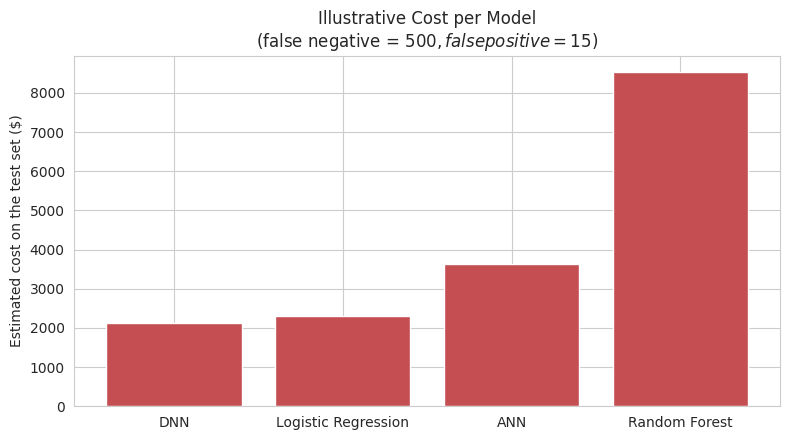

Under these illustrative costs, the lowest-cost model on the test set is: DNN


In [30]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(cost_df['Model'], cost_df['Estimated Cost ($)'], color='#C44E52')
ax.set_ylabel('Estimated cost on the test set ($)')
ax.set_title(f'Illustrative Cost per Model\n(false negative = ${COST_PER_MISSED_FRAUD}, false positive = ${COST_PER_FALSE_ALARM})')
plt.tight_layout()
plt.show()

best_model_by_cost = cost_df.iloc[0]['Model']
print(f"Under these illustrative costs, the lowest-cost model on the test set is: {best_model_by_cost}")

**Why this matters more than accuracy:** two models with near-identical accuracy can imply very different
total costs once false negatives and false positives are weighted correctly, because fraud losses and investigation
costs are rarely symmetric. **The right move for the bank is to plug in its own real cost estimates** (average fraud
loss, cost of an investigator-hour, estimated customer-churn cost of a false decline) and re-run this comparison —
the ranking above will shift accordingly, and the decision-threshold on the winning model's probability output can
then be tuned to minimize *that* number rather than to maximize accuracy.

### 🎯 BQ4 — Answer
**Yes, this is technically feasible for real-time use** — inference latency is negligible for every model tested,
so the constraint on deployment is governance and validation, not compute. **The metric that should drive the
model/threshold decision is a cost-weighted combination of false negatives and false positives**, not raw accuracy
or even F1 in isolation — because the bank's actual losses depend on the (asymmetric) dollar cost of each error type.


### 7.3 Persisting the Model for Deployment

In [31]:
import joblib, os

os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(lr_model, '../models/logistic_regression_model.pkl')
joblib.dump(scaler_model, '../models/feature_scaler.pkl')
ann_model.save('../models/ann_model.keras')
dnn_model.save('../models/dnn_model.keras')

print("Models saved to ../models/")
print(os.listdir('../models'))

Models saved to ../models/
['logistic_regression_model.pkl', 'ann_model.keras', 'dnn_model.keras', 'random_forest_model.pkl', 'feature_scaler.pkl']


---
# 8. Business Conclusions & Recommendations

## Answering Each Business Question

**BQ1 — Can pattern-based detection find fraud in unlabeled data?**
Not with naive K-Means on the full feature set: it rediscovers demographic groupings (occupation, age) rather
than fraud behavior. But once demographic noise is removed, K-Means and Isolation Forest substantially converge
(87% of K-Means' flagged transactions were independently confirmed by Isolation Forest), both pointing to
login-attempt anomalies as the dominant signal. **Isolation Forest on behavioral features** was adopted as the
working proxy label — it lines up with recognizable fraud typologies (elevated login attempts, balance/amount
anomalies, account dormancy) — and this is what the supervised models were trained on.

**BQ2 — Which model supports good operational decisions?**
There is a genuine precision/recall trade-off across the four models (see Section 6.1): Random Forest favors
precision, Logistic Regression favors recall, and ANN/DNN sit in between with the strongest ROC-AUC. Measured
concretely, ANN and DNN deliver a materially higher F1-score on the fraud class than Random Forest — the added
complexity of deep learning **is justified by a real performance gain here**, not just theoretical upside, provided
the underlying label is validated first. For a first pilot where auditability matters most, Random Forest/Logistic
Regression remain the safer starting point; the deep learning gain is real but should be a deliberate choice, not
a default.

**BQ3 — What fraud indicators can the risk team act on?**
Behavioral signals (login attempts, balance-to-amount ratio, transaction dormancy) dominate the importance
ranking — well ahead of demographic factors. Looked at more strategically, **account-level behavior carries far
more predictive weight than transaction-level characteristics**, which argues for a two-tier mitigation design:
continuous account-risk monitoring as the primary defense, with fast transaction-level checks layered on top at
authorization time. A simple two-threshold rule already captures a meaningful share of what the full model flags.

**BQ4 — Is this feasible in production?**
Yes, from a latency standpoint — every model scores a transaction in under a millisecond. The real gating factor
is validating the working label against real investigated cases, and choosing a decision threshold based on the
bank's actual cost of a missed fraud vs. a false alarm, not on accuracy alone.

## Recommendations
1. **Validate the working label before trusting any model number.** Sample a batch of Isolation-Forest-flagged
   transactions and have the fraud team manually confirm/reject them — this converts a proxy label into (partial)
   ground truth and lets every metric above be re-checked against reality.
2. **Start with Random Forest (or Logistic Regression) in a shadow-mode pilot**, not deep learning — cheaper,
   faster to iterate, and easier to explain to auditors, unless the deep models' AUC/F1 advantage proves large and
   consistent once validated on real labels.
3. **Build the simple behavioral rule as an interim safety net** while the model is being validated, and use it
   as a sanity check on the model's outputs going forward.
4. **Set the decision threshold using a real cost matrix**, not a default 0.5 cutoff — plug the bank's actual
   fraud-loss and investigation-cost figures into the Section 7.2 framework.
5. **Exclude or closely monitor demographic features in production** to avoid disparate-impact risk, even though
   they ranked low in importance here.

## Limitations
- The fraud label used throughout is a **proxy generated by an unsupervised method**, not confirmed by a human
  investigator — every accuracy/precision/recall number describes how well models learned *that proxy*, not
  necessarily real-world fraud.
- This is a **relatively small, likely synthetic dataset** (2,512 transactions); patterns here may not generalize
  to a bank's actual transaction volume and fraud mix.
- **No concept-drift or monitoring plan** has been implemented — fraud patterns evolve, and a static model will
  degrade over time without retraining and monitoring.
- The illustrative cost figures in Section 7.2 are placeholders — they must be replaced with the institution's
  real loss and investigation-cost data before being used for a threshold decision.

## Roadmap
- [ ] Manual review/validation of a labeled sample to check the Isolation Forest proxy against real investigator judgment
- [ ] Hyperparameter tuning and threshold optimization against a real cost matrix
- [ ] SMOTE / other imbalance-handling techniques as an alternative to class weighting
- [ ] A lightweight FastAPI scoring service wrapping the chosen model
- [ ] Drift monitoring and a scheduled retraining cadence
- [ ] Graph/network features from account–merchant relationships for a future iteration

---
## 📞 Contact
**Defrizal Yahdiyan Risyad** — defrijay@gmail.com
